<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_8/Chapter08/dimensionality_reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Dimensionality Reduction

## Main approaches for Dimensionality Reduction

Two main approaches
- Projection
- Manifold Learning

### Projection

In most real-world problems:
- Many features are almost constant
  - eg. a sensor that always reads ~25.0 ± 0.01
- Highly correlated
  - eg. CPU usage vs power consumption (If you know one, you can predict the other)

All training instances lie within / or close to a much lower-dimensional subspace of the high-dimensional space

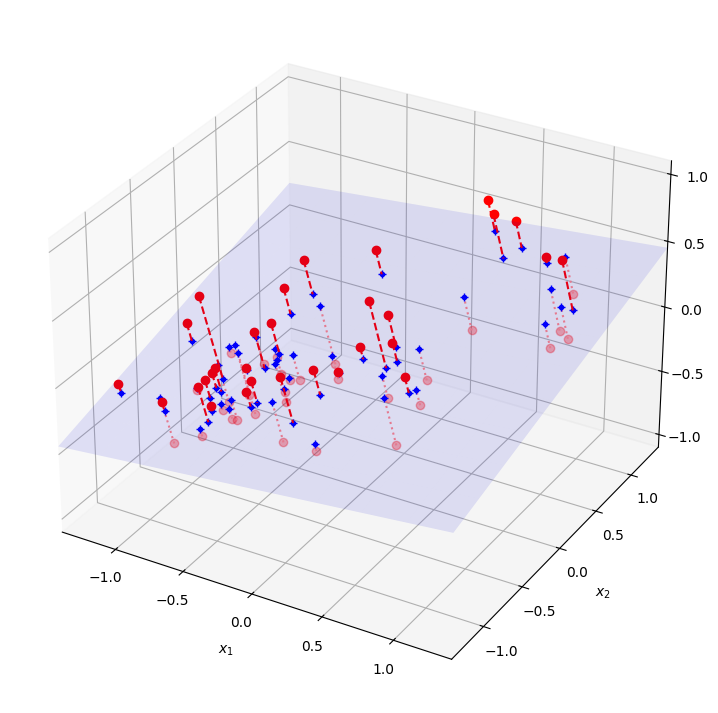

In [1]:
# 3D dataset lying close to a 2D subspace

import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3))  # initialize 3D dataset
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # uneven distribution
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # oval
X += 0.28 * np.random.randn(m, 3)  # add more noise
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2]  # shift a bit

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)  # dataset reduced to 2D
X3D_inv = pca.inverse_transform(X2D)  # 3D position of the projected samples
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)

axes = [-1.4, 1.4, -1.4, 1.4, -1.1, 1.1]
x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 10),
                     np.linspace(axes[2], axes[3], 10))
w1, w2 = np.linalg.solve(Vt[:2, :2], Vt[:2, 2])  # projection plane coefs
z = w1 * (x1 - pca.mean_[0]) + w2 * (x2 - pca.mean_[1]) - pca.mean_[2]  # plane
X3D_above = X[X[:, 2] >= X3D_inv[:, 2]]  # samples above plane
X3D_below = X[X[:, 2] < X3D_inv[:, 2]]  # samples below plane

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection="3d")

# plot samples and projection lines below plane first
ax.plot(X3D_below[:, 0], X3D_below[:, 1], X3D_below[:, 2], "ro", alpha=0.3)
for i in range(m):
    if X[i, 2] < X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], ":", color="#F88")

ax.plot_surface(x1, x2, z, alpha=0.1, color="b")  # projection plane
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b+")  # projected samples
ax.plot(X3D_inv[:, 0], X3D_inv[:, 1], X3D_inv[:, 2], "b.")

# now plot projection lines and samples above plane
for i in range(m):
    if X[i, 2] >= X3D_inv[i, 2]:
        ax.plot([X[i][0], X3D_inv[i][0]],
                [X[i][1], X3D_inv[i][1]],
                [X[i][2], X3D_inv[i][2]], "r--")

ax.plot(X3D_above[:, 0], X3D_above[:, 1], X3D_above[:, 2], "ro")

def set_xyz_axes(ax, axes):
    ax.xaxis.set_rotate_label(False)
    ax.yaxis.set_rotate_label(False)
    ax.zaxis.set_rotate_label(False)
    ax.set_xlabel("$x_1$", labelpad=8, rotation=0)
    ax.set_ylabel("$x_2$", labelpad=8, rotation=0)
    ax.set_zlabel("$x_3$", labelpad=8, rotation=0)
    ax.set_xlim(axes[0:2])
    ax.set_ylim(axes[2:4])
    ax.set_zlim(axes[4:6])

set_xyz_axes(ax, axes)
ax.set_zticks([-1, -0.5, 0, 0.5, 1])

plt.show()

- Trainings instances lie close to a plane
- If project every instance perpendicular onto this subspace, can get a 2D dataset

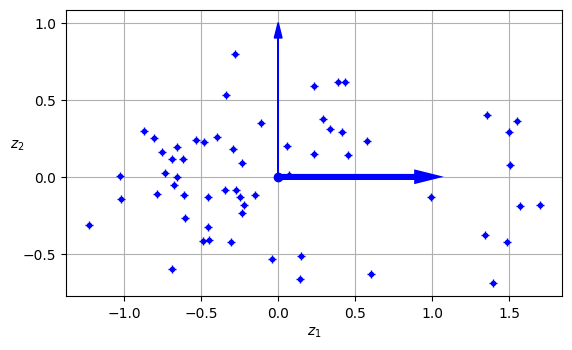

In [2]:
# Reduction from 3D to 2D

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, aspect='equal')
ax.plot(X2D[:, 0], X2D[:, 1], "b+")
ax.plot(X2D[:, 0], X2D[:, 1], "b.")
ax.plot([0], [0], "bo")
ax.arrow(0, 0, 1, 0, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=4)
ax.arrow(0, 0, 0, 1, head_width=0.05, length_includes_head=True,
         head_length=0.1, fc='b', ec='b', linewidth=1)
ax.set_xlabel("$z_1$")
ax.set_yticks([-0.5, 0, 0.5, 1])
ax.set_ylabel("$z_2$", rotation=0)
ax.set_axisbelow(True)
ax.grid(True)

### Manifold Learning

- Projection is not always the best approach
- In many cases the subsapce may twist and turn, eg. Swiss roll toy dataset
- A d-dimensional manifold is a part of an n-dimensional space (where d < n)

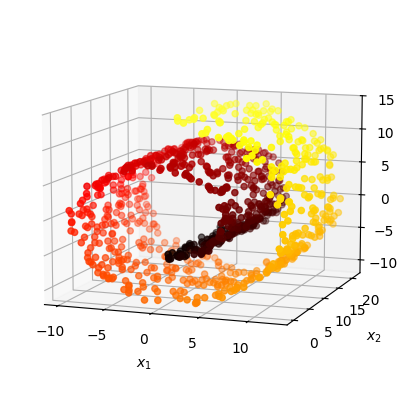

In [3]:
from sklearn.datasets import make_swiss_roll

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)


from matplotlib.colors import ListedColormap

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))

axes = [-11.5, 14, -2, 23, -12, 15]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t, cmap=darker_hot)
ax.view_init(10, -70)
set_xyz_axes(ax, axes)

plt.show()

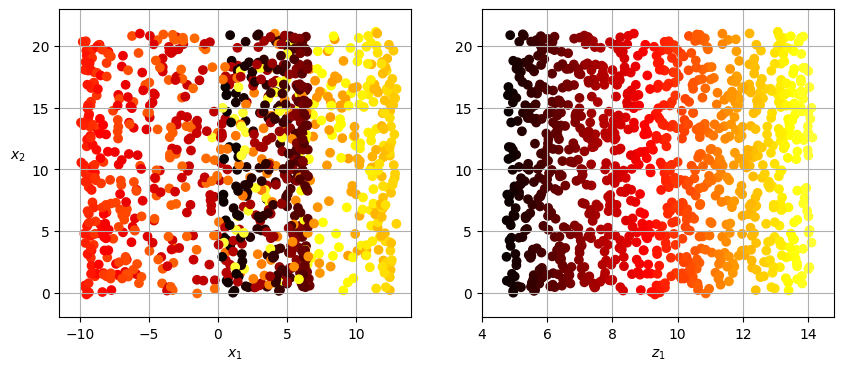

In [4]:
# Simply projecting onto a plane would squash different layers of the Swiss roll together
# Required to unroll to obtain the datatset like figure on the right

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.scatter(X_swiss[:, 0], X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis(axes[:4])
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", labelpad=10, rotation=0)
plt.grid(True)

plt.subplot(122)
plt.scatter(t, X_swiss[:, 1], c=t, cmap=darker_hot)
plt.axis([4, 14.8, axes[2], axes[3]])
plt.xlabel("$z_1$")
plt.grid(True)

plt.show()

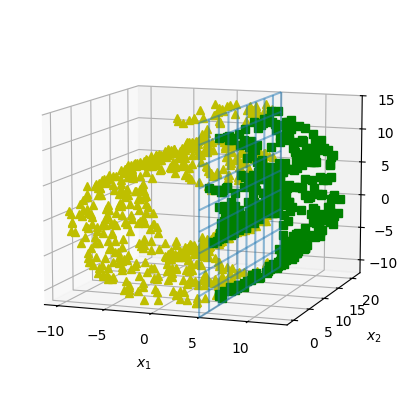

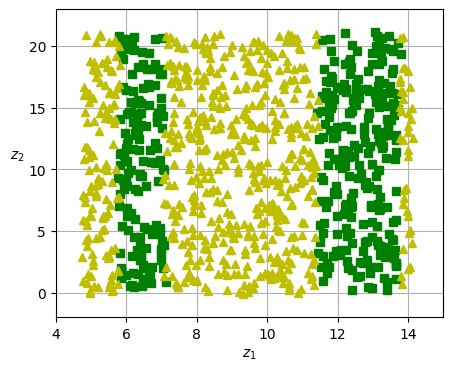

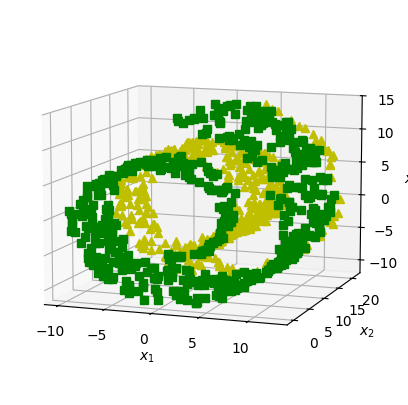

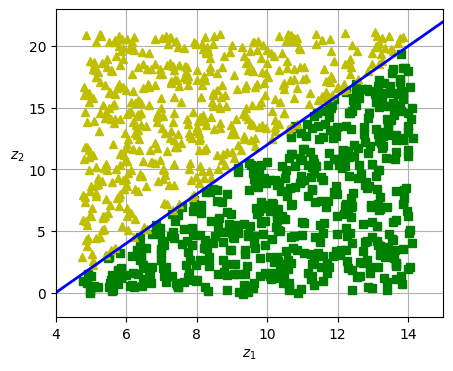

In [5]:
# Decision boundary many not always be simpler with lower dimensions
# eg. at x1= 5, looks simple in 3D but complex in unrolled manifold

axes = [-11.5, 14, -2, 23, -12, 15]
x2s = np.linspace(axes[2], axes[3], 10)
x3s = np.linspace(axes[4], axes[5], 10)
x2, x3 = np.meshgrid(x2s, x3s)

positive_class = X_swiss[:, 0] > 5
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot_wireframe(5, x2, x3, alpha=0.5)
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
set_xyz_axes(ax, axes)
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
plt.show()

positive_class = 2 * (t[:] - 4) > X_swiss[:, 1]
X_pos = X_swiss[positive_class]
X_neg = X_swiss[~positive_class]

fig = plt.figure(figsize=(6, 5))
ax = plt.subplot(1, 1, 1, projection='3d')
ax.view_init(10, -70)
ax.plot(X_neg[:, 0], X_neg[:, 1], X_neg[:, 2], "y^")
ax.plot(X_pos[:, 0], X_pos[:, 1], X_pos[:, 2], "gs")
ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.set_xlabel("$x_1$", rotation=0)
ax.set_ylabel("$x_2$", rotation=0)
ax.set_zlabel("$x_3$", rotation=0)
ax.set_xlim(axes[0:2])
ax.set_ylim(axes[2:4])
ax.set_zlim(axes[4:6])
plt.show()

fig = plt.figure(figsize=(5, 4))
ax = plt.subplot(1, 1, 1)
ax.plot(t[positive_class], X_swiss[positive_class, 1], "gs")
ax.plot(t[~positive_class], X_swiss[~positive_class, 1], "y^")
ax.plot([4, 15], [0, 22], "b-", linewidth=2)
ax.axis([4, 15, axes[2], axes[3]])
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$", rotation=0, labelpad=8)
ax.grid(True)
plt.show()

## PCA (Principal Component Analysis)

- Most popular dimensionality reduction algorithm
- Identifies the hyperplane that lies closest to the data
- then projects the data onto the plane

### Preserving the Variance

- Need to choose the right hyperplane
- Select the axis that preserves the maximum amount of variance, lose less information

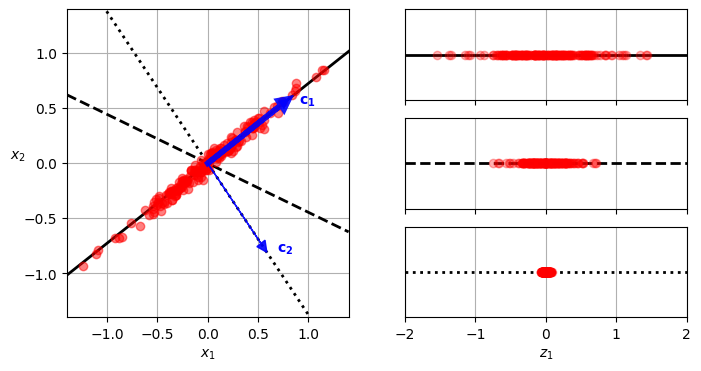

In [6]:
# Example of 2D dataset with 3 different axes

angle = np.pi / 5
stretch = 5
m = 200

np.random.seed(3)
X_line = np.random.randn(m, 2) / 10
X_line = X_line @ np.array([[stretch, 0], [0, 1]])  # stretch
X_line = X_line @ [[np.cos(angle), np.sin(angle)],
                   [np.sin(angle), np.cos(angle)]]  # rotate

u1 = np.array([np.cos(angle), np.sin(angle)])
u2 = np.array([np.cos(angle - 2 * np.pi / 6), np.sin(angle - 2 * np.pi / 6)])
u3 = np.array([np.cos(angle - np.pi / 2), np.sin(angle - np.pi / 2)])

X_proj1 = X_line @ u1.reshape(-1, 1)
X_proj2 = X_line @ u2.reshape(-1, 1)
X_proj3 = X_line @ u3.reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.subplot2grid((3, 2), (0, 0), rowspan=3)
plt.plot([-1.4, 1.4], [-1.4 * u1[1] / u1[0], 1.4 * u1[1] / u1[0]], "k-",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u2[1] / u2[0], 1.4 * u2[1] / u2[0]], "k--",
         linewidth=2)
plt.plot([-1.4, 1.4], [-1.4 * u3[1] / u3[0], 1.4 * u3[1] / u3[0]], "k:",
         linewidth=2)
plt.plot(X_line[:, 0], X_line[:, 1], "ro", alpha=0.5)
plt.arrow(0, 0, u1[0], u1[1], head_width=0.1, linewidth=4, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.arrow(0, 0, u3[0], u3[1], head_width=0.1, linewidth=1, alpha=0.9,
          length_includes_head=True, head_length=0.1, fc="b", ec="b", zorder=10)
plt.text(u1[0] + 0.1, u1[1] - 0.05, r"$\mathbf{c_1}$", color="blue")
plt.text(u3[0] + 0.1, u3[1], r"$\mathbf{c_2}$", color="blue")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.axis([-1.4, 1.4, -1.4, 1.4])
plt.grid()

plt.subplot2grid((3, 2), (0, 1))
plt.plot([-2, 2], [0, 0], "k-", linewidth=2)
plt.plot(X_proj1[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (1, 1))
plt.plot([-2, 2], [0, 0], "k--", linewidth=2)
plt.plot(X_proj2[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.gca().get_xaxis().set_ticklabels([])
plt.axis([-2, 2, -1, 1])
plt.grid()

plt.subplot2grid((3, 2), (2, 1))
plt.plot([-2, 2], [0, 0], "k:", linewidth=2)
plt.plot(X_proj3[:, 0], np.zeros(m), "ro", alpha=0.3)
plt.gca().get_yaxis().set_ticks([])
plt.axis([-2, 2, -1, 1])
plt.xlabel("$z_1$")
plt.grid()

plt.show()

### Principal Components

- The first axis captures the maximum variance
- The second axis captures the next highest variance
- Each new axis is orthogonal (perpendicular) to the previous ones
- PCA would find as many axes as the number of dimensions in the dataset
- The $i^{th}$ axis is called the $i^{th}$ *principal component* of the data

- How to find the principal component of a training set?
  - Use standard matrix factorization technique called *singular value decomposition* (SVD)
  - SVD factorization algorithm returns three matrices, $U$, $Σ$ and $V$, such that $X = U Σ V^⊺$, where $U$ is an $m × m$ matrix, $Σ$ is an $m × n$ matrix, and $V$ is an $n × n$ matrix. But the svd() function returns $U$, $s$ and $V^⊺$ instead. $s$ is the vector containing all the values on the main diagonal of the top $n$ rows of $Σ$.

In [7]:
import numpy as np

# X = [...]  # the small 3D dataset was created earlier in this notebook
X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

In [8]:
m, n = X.shape
Σ = np.zeros_like(X_centered)
Σ[:n, :n] = np.diag(s)
assert np.allclose(X_centered, U @ Σ @ Vt)

### Projecting Down to d Dimensions

- Once all the principal components are identified, the dimensionality of the dataset can be reduced to *d* dimensions by projecting it onto the hyperplane defined by the first *d* principal components
- The projection preserves as much variance as possible
- Equation to project training set down to d dimensions
$$
X_{d-proj} = XW_d
$$

In [9]:
# Projects the training set onto the plane defined by the first two principal components

W2 = Vt[:2].T
X2D = X_centered @ W2

### Using Scikit-Learn

- Scikit-Learn's PCA class uses SVD to implement PCA
- After fitting PCA transformer to the dataset, its components_ attribute holds the transpose of $W_d$
- The attribute contains one row for each of the first d principal components

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

In [11]:
pca.components_

array([[ 0.67857588,  0.70073508,  0.22023881],
       [ 0.72817329, -0.6811147 , -0.07646185]])

### Explained Variance Ratio

- The ratio indicates the proportion of the dataset's variance that lies along each principal component
- Use principal_variance_ratio_ variable to get the ratio

In [12]:
pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

- First dimension explains about 76% of the variance
- Second dimension explains about 15%

In [13]:
1 - pca.explained_variance_ratio_.sum()

np.float64(0.09028309326742057)

- Projecting down the dimension, lose about 9% of the variance

### Choosing the Right Number of Dimensions

- Instead of choosing the number of dimensions to reduce down to, we can choose the number of of dimensions that add up to a sufficiently large portion of the variance
- Exception: Dimensionality reduction for data visualization, required to be down to 2 or 3

In [14]:
# 1. Split MNIST dataset
# 2. Performs PCA without reducing dimensionality
# 3. Computes the number of dimensions required to preserve 95% of the training set's variance

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X_train, y_train = mnist["data"][:60000], mnist["target"][:60000]
X_test, y_test = mnist["data"][60000:], mnist["target"][60000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
print(d)

154


In [15]:
# Could set n_components=d
# OR
# A float between 0.0 and 1.0
pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

# Actual number of components is determined during training
print("Number of Components:", pca.n_components_)

print("Ratio:", pca.explained_variance_ratio_.sum())

Number of Components: 154
Ratio: 0.9501960192613031


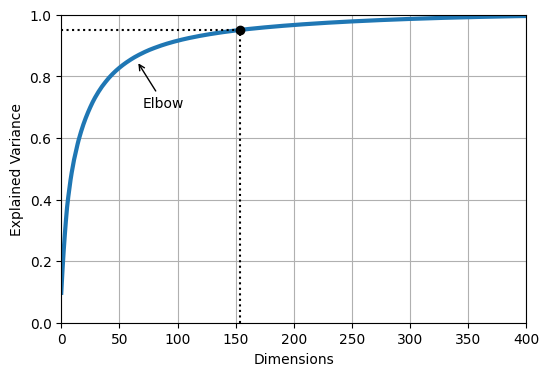

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True)
plt.show()

- Using dimensionality reduction as a preprocessing step for a supervised learning task (e.g. classification)
- The following example creates a two-step pipeline
  - 1. Reduce dimensionality using PCA
  - 2. Use RandomizedSearchCV to find a good combination of hyperparameters for both PCA and the random forest clasifier

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       6...
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       492, 493, 494, 495, 496, 497, 498, 499])},
                   random_state=42)

In [18]:
print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


- Using random forest reduced a 784-dimensional dataset to just 23 dimensions
- Below example use linear model (SGDClassifier)

In [19]:
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV

clf = make_pipeline(PCA(random_state=42), SGDClassifier())
param_grid = {"pca__n_components": np.arange(10, 80)}
grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X_train[:1000], y_train[:1000])

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                       ('sgdclassifier', SGDClassifier())]),
             param_grid={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79])})

In [20]:
grid_search.best_params_

{'pca__n_components': np.int64(67)}

### PCA for Compression

- Training dataset takes up much lesser space after dimensionality reduction
- Example on applying PCA to MNIST above
  - Preserved 95% of its variance
  - Reduced from 784 features (28x28 pixels) to 154 features
  - Dataset is 20% lesser than its original size with only 5% variance loss
- PCA inverse transformation
  - decompress reduced dataset back
  - Unable to get original data back, since the projection lose a bit of information

$$
X_{recovered} = X_{d-proj}{W_d}^T
$$

In [21]:
# inverse_transform() decompress the reduced dataset back to 784 dimensions

X_recovered = pca.inverse_transform(X_reduced)

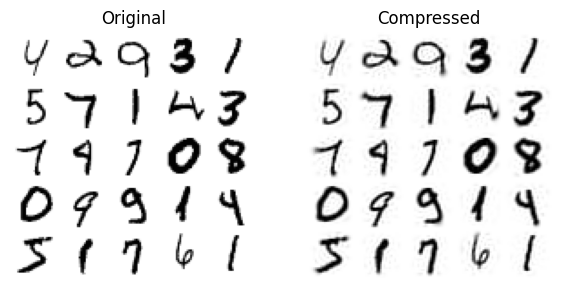

In [22]:
# Plot digits after compression and decompression

plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100], X_recovered[::2100])):
    plt.subplot(1, 2, idx + 1)
    plt.title(["Original", "Compressed"][idx])
    for row in range(5):
        for col in range(5):
            plt.imshow(X[row * 5 + col].reshape(28, 28), cmap="binary",
                       vmin=0, vmax=255, extent=(row, row + 1, col, col + 1))
            plt.axis([0, 5, 0, 5])
            plt.axis("off")

### Randomized PCA

- Set svd_solve to "randomized"
- Uses a stochastic algorithm that quickly finds an approximation of the first d principal components
- Faster than full SVD when d is much smaller than n

In [23]:
rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

### Incremental PCA

- Preceding implementations require the whole training set to fir in memory for the algorithm to run
- Incremental PCA allows training set to be split into mini-batches
- Useful for large training sets and for applying PCA online
- Use NumPy's array_split() to split the training set then feed into Scikit-Learn's IncrementalPCA class

In [24]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced = inc_pca.transform(X_train)

Using NumPy's memmap class – a memory-map to an array stored in a binary file on disk.

Let's create the memmap instance, copy the MNIST training set into it, and call flush() which ensures that any data still in cache is saved to disk. This would typically be done by a first program:

In [25]:
filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train  # could be a loop instead, saving the data chunk by chunk
X_mmap.flush()

In [26]:
X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

IncrementalPCA(batch_size=600, n_components=154)

### Random Projection

- Training may become very slow for dataset with tens of thousands of features or more
- Random projection projects the data to a lower dimensional space using a random linear projection
- For an example dataset of m=5000 instances with n=20000 features each, and keep the squared distance between any two instances less than $ɛ=10\%^{6}$, dataset should project down to d dimensions:
  - $$
d ≥ \frac {4 log(m)}{\frac{1}{2}ε^2 - \frac{1}{3}ε^3}
  $$
  - whicd d is 7300 dimensions

In [27]:
m, ε = 5_000, 0.1

d = int(4 * np.log(m) / (ε ** 2 / 2 - ε ** 3 / 3))
d

7300

- The above equation can be implemented using the johnson_lindenstrauss_min_dim() function

In [28]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

d = johnson_lindenstrauss_min_dim(m, eps=ε)
d

np.int64(7300)

In [29]:
# Project from n dimensions down to d

n = 20_000
np.random.seed(42)
P = np.random.randn(d, n) / np.sqrt(d)  # std dev = square root of variance

X = np.random.randn(m, n)  # generate a fake dataset
X_reduced = X @ P.T

- Scikit-Learn offers a GaussianRandomProjection class to do implement the above projection

In [30]:
from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=ε, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)  # same result as above

- To perform the inverse transformation:
  - Compute the pseudo-inverse of the components matrix using SciPy's pinv() function
  - then multiply the reduced data by the transpose of the pseudo-inverse

In [31]:
# Inverse transformation

components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

- Scikit-Learn provides a second random projection transformer (SparseRandomProjection)
- Same as johnson_lindenstrauss_min_dim() except that the random matrix is sparse
- Uses much lesser memory and faster for generating random matrix and reducing dimensionality
- It's usually preferable to use this transformer instead of the previous one

In [32]:
from sklearn.random_projection import SparseRandomProjection

print("GaussianRandomProjection fit")
%timeit GaussianRandomProjection(random_state=42).fit(X)
print("SparseRandomProjection fit")
%timeit SparseRandomProjection(random_state=42).fit(X)

gaussian_rnd_proj = GaussianRandomProjection(random_state=42).fit(X)
sparse_rnd_proj = SparseRandomProjection(random_state=42).fit(X)
print("GaussianRandomProjection transform")
%timeit gaussian_rnd_proj.transform(X)
print("SparseRandomProjection transform")
%timeit sparse_rnd_proj.transform(X)

GaussianRandomProjection fit
5.1 s ± 469 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjection fit
3.72 s ± 632 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
GaussianRandomProjection transform
43.5 s ± 350 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
SparseRandomProjection transform
5.71 s ± 233 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## LLE

- Locally linear embedding
- A nonlinear dimensionality reduction technique (manifold learning technique)

In [33]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

# t is a 1D NumPy array containing the position of each instance along the rolled axis
X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_neighbors=10, n_components=2, random_state=42)
X_unrolled = lle.fit_transform(X_swiss)

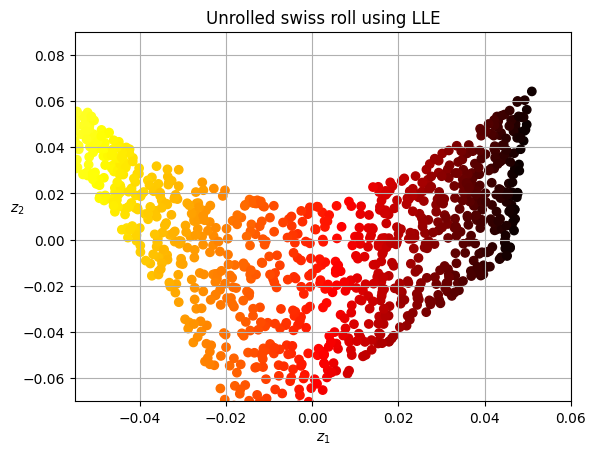

In [34]:
plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1],
            c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
plt.axis([-0.055, 0.060, -0.070, 0.090])
plt.grid(True)

plt.title("Unrolled swiss roll using LLE")
plt.show()

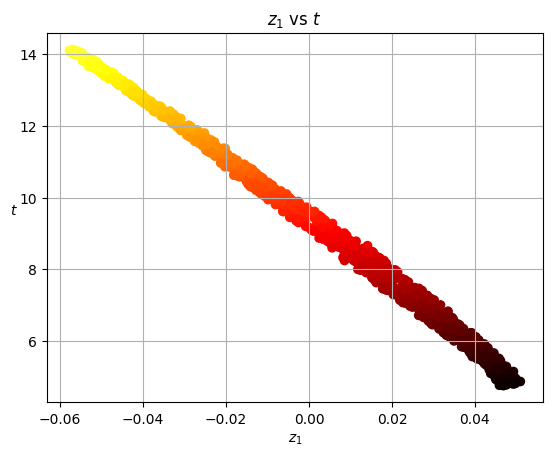

In [35]:
# Shows how well correlated z1 is to t: LLE worked fine
plt.title("$z_1$ vs $t$")
plt.scatter(X_unrolled[:, 0], t, c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$t$", rotation=0)
plt.grid(True)
plt.show()

## Other Dimensionality Reduction Techniques

Multidimensional scaling (MDS)
- Reduce dimensionality while trying to preserve the distances between the instances
- Random projectiong does this for high-dimensional data, but doesn't work well on low-dimensional data

In [37]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, normalized_stress=False, random_state=42)
X_reduced_mds = mds.fit_transform(X_swiss)

Isomap
- Creates a graph by connecting each instance to its nearest neighbors
- Trying to preserve the geodesic distances between the instances
- The geodisc distance between two nodes in a graph is the number of nodes on the shortest path between these nodes

In [38]:
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_reduced_isomap = isomap.fit_transform(X_swiss)

t-distributed stochastic neighbor embedding (t-SNE)
- Trying to keep similar instances close and dissimilar instances apart
- Used for visualization
- Visualize clusters on instances in high dimensional space

In [39]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
X_reduced_tsne = tsne.fit_transform(X_swiss)

Linear discriminant analysis (LDA)
- Linear classification algorithm
- Learns the most discriminative axes between the classes
- Axes can be used to define hyperplane
- Projection will keep classes as far apart as possible

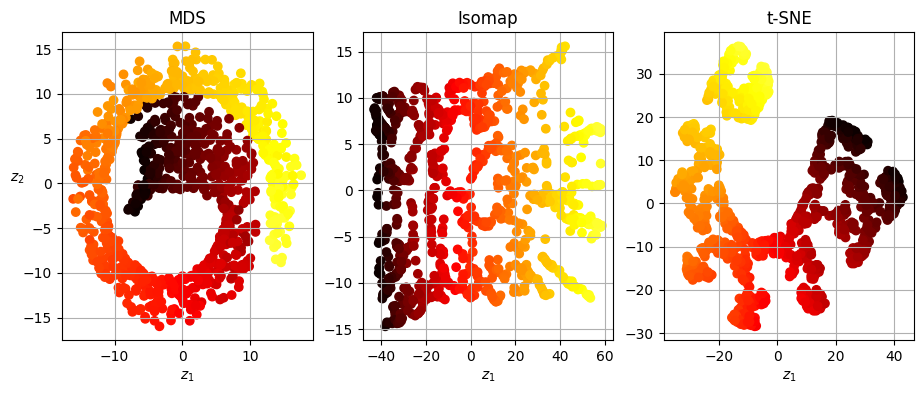

In [40]:
# Plot of MDS, Isomap, and t-SNE on the Swiss roll

titles = ["MDS", "Isomap", "t-SNE"]

plt.figure(figsize=(11, 4))

for subplot, title, X_reduced in zip((131, 132, 133), titles,
                                     (X_reduced_mds, X_reduced_isomap, X_reduced_tsne)):
    plt.subplot(subplot)
    plt.title(title)
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=t, cmap=darker_hot)
    plt.xlabel("$z_1$")
    if subplot == 131:
        plt.ylabel("$z_2$", rotation=0)
    plt.grid(True)

plt.show()

## Exercises

1. What are the main motivations for reducing a dataset's dimensionality? What are the main drawbacks?
   - Motivations:
     - Speed up a subsequent training algorithm (in some cases it may even remove noise and redundant features, making the training algorithm perform better)
     - Visualize the data and gain insights on the most important features
     - Save space (compression)
   - Drawbacks:
     - Some information is lost, possibly degrading the performance of subsequent training algorithms.
     - It can be computationally intensive.
     - It adds some complexity to your Machine Learning pipelines.
     - Transformed features are often hard to interpret.

2. What is the curse of dimensionality?
   - The curse of dimensionality refers to the fact that many problems that do not exist in low-dimensional space arise in high-dimensional space. In Machine Learning, one common manifestation is the fact that randomly sampled high-dimensional vectors are generally far from one another, increasing the risk of overfitting and making it very difficult to identify patterns without having plenty of training data.

3. Once a dataset's dimensionality has been reduced, is it possible to reverse the operation? If so, how? If not, why?
   - It is almost always impossible to perfectly reverse the operation, because some information gets lost during dimensionality reduction. Moreover, while some algorithms (such as PCA) have a simple reverse transformation procedure that can reconstruct a dataset relatively similar to the original, other algorithms (such as t-SNE) do not.



4. Can PCA be used to reduce the dimensionality of a highly nonlinear dataset?
   - PCA can be used to significantly reduce the dimensionality of most datasets, even if they are highly nonlinear, because it can at least get rid of useless dimensions. However, if there are no useless dimensions—as in the Swiss roll dataset—then reducing dimensionality with PCA will lose too much information. You want to unroll the Swiss roll, not squash it.

5. Suppose you perform PCA on a 1000-dimensional dataset, setting the explained variance ratio to 95%. How many dimensions will the resuilting dataset have?
   - It depends on the dataset. Let's look at two extreme examples. First, suppose the dataset is composed of points that are almost perfectly aligned. In this case, PCA can reduce the dataset down to just one dimension while still preserving 95% of the variance. Now imagine that the dataset is composed of perfectly random points, scattered all around the 1,000 dimensions. In this case roughly 950 dimensions are required to preserve 95% of the variance. So the answer is, it depends on the dataset, and it could be any number between 1 and 950. Plotting the explained variance as a function of the number of dimensions is one way to get a rough idea of the dataset's intrinsic dimensionality.

6. In what cases would you use regular PCA, incremental PCA, randomized PCA, or random projection?
   - Regular PCA is the default, but it works only if the dataset fits in memory. Incremental PCA is useful for large datasets that don't fit in memory, but it is slower than regular PCA, so if the dataset fits in memory you should prefer regular PCA. Incremental PCA is also useful for online tasks, when you need to apply PCA on the fly, every time a new instance arrives. Randomized PCA is useful when you want to considerably reduce dimensionality and the dataset fits in memory; in this case, it is much faster than regular PCA. Finally, Random Projection is great for very high-dimensional datasets.

7. How can you evaluate the performance of a dimensionaltiy reduction algorithm on your dataset?
   - Dimensionality reduction algorithm performs well if it eliminates a lot of dimensions from the dataset without losing too much information. One way to measure this is to apply the reverse transformation and measure the reconstruction error. However, not all dimensionality reduction algorithms provide a reverse transformation. Alternatively, if you are using dimensionality reduction as a preprocessing step before another Machine Learning algorithm (e.g., a Random Forest classifier), then you can simply measure the performance of that second algorithm; if dimensionality reduction did not lose too much information, then the algorithm should perform just as well as when using the original dataset.

8. Does it make any sense to chain two different dimensionality reduction algorithm on your dataset?
   - It can absolutely make sense to chain two different dimensionality reduction algorithms. A common example is using PCA or Random Projection to quickly get rid of a large number of useless dimensions, then applying another much slower dimensionality reduction algorithm, such as LLE. This two-step approach will likely yield roughly the same performance as using LLE only, but in a fraction of the time.

9. Load the MNIST datset (introduced in Chapter 3) and split it into a training set and a test set (take the first 60000 instances for training, and the remaining 10000 for testing). Train a random forest classifier on the datset and time how long it takes, then evaluate the resulting model on the test set. Next, use PCA to reduce the dataset's dimensionality, with an explained variance ratio of 95%. Train a new random forest classifier on the reduced dataset and see how long it takes. Was training much faster? Next, evaluate the classifier on the test set. How does it compare to the previous classifier? Try again with an SGDClassifier. How much does PCA help now?

In [41]:
X_train = mnist.data[:60000]
y_train = mnist.target[:60000]

X_test = mnist.data[60000:]
y_test = mnist.target[60000:]

In [42]:
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)

In [43]:
%time rnd_clf.fit(X_train, y_train)

CPU times: user 1min 5s, sys: 287 ms, total: 1min 5s
Wall time: 1min 11s


RandomForestClassifier(random_state=42)

In [44]:
from sklearn.metrics import accuracy_score

y_pred = rnd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9705

In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)

In [46]:
rnd_clf_w_pca = RandomForestClassifier(n_estimators=100, random_state=42)
%time rnd_clf_w_pca.fit(X_train_reduced, y_train)

CPU times: user 3min 29s, sys: 392 ms, total: 3min 30s
Wall time: 4min 13s


RandomForestClassifier(random_state=42)

In [47]:
X_test_reduced = pca.transform(X_test)

y_pred_reduced = rnd_clf_w_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pred_reduced)

0.9488

In [48]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
%time sgd_clf.fit(X_train, y_train)

CPU times: user 3min 29s, sys: 345 ms, total: 3min 29s
Wall time: 4min 13s


SGDClassifier(random_state=42)

In [49]:
y_pred_sgd = sgd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9705

In [50]:
sgd_clf_w_pca = SGDClassifier(random_state=42)
%time sgd_clf_w_pca.fit(X_train_reduced, y_train)

CPU times: user 51.6 s, sys: 69.9 ms, total: 51.6 s
Wall time: 1min 4s


SGDClassifier(random_state=42)

In [51]:
y_pred_sgd_reduced = sgd_clf_w_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pred_sgd_reduced)

0.8959

10. Use t-SNE to reduce the first 5000 images of the MNIST dataset down to 2 dimensions and plot the result using Matplotlib. You can use a scatterplot using 10 different colors to represent each image's target class. Alternatively, you can replace each dot in the scatterplot with th corresponding instance's class (a digit from 0 to 9), or even plot scaled-down versions of the digit imges themselves (if you plot all digits the visualization will be too cluttered, so you could either draw a random sample or plot on instance only if no other instance has already been plotted at a close distance). You should get a nice visualization with well-separated clusters of digits. Try using other dimensionality reduction algorithms, such as PCA, LLE, or MDS, and compaore the resulting visualizations.

In [52]:
X_sample, y_sample = X_train[:5000], y_train[:5000]

In [53]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
%time X_reduced = tsne.fit_transform(X_sample)

CPU times: user 1min, sys: 72.5 ms, total: 1min 1s
Wall time: 1min 1s


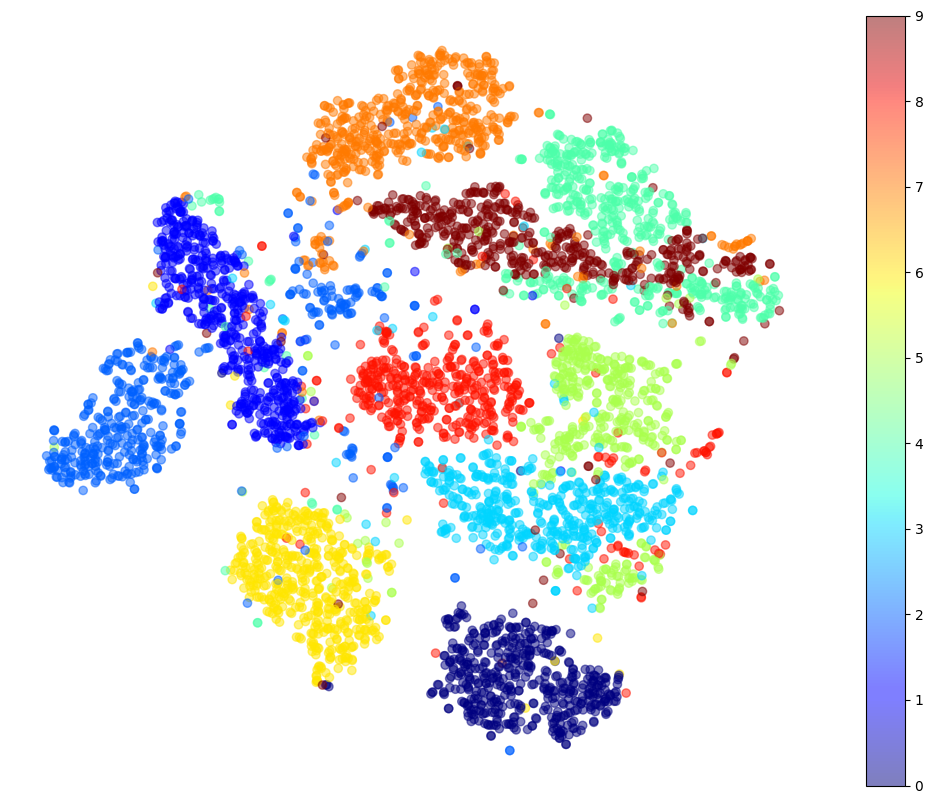

In [54]:
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

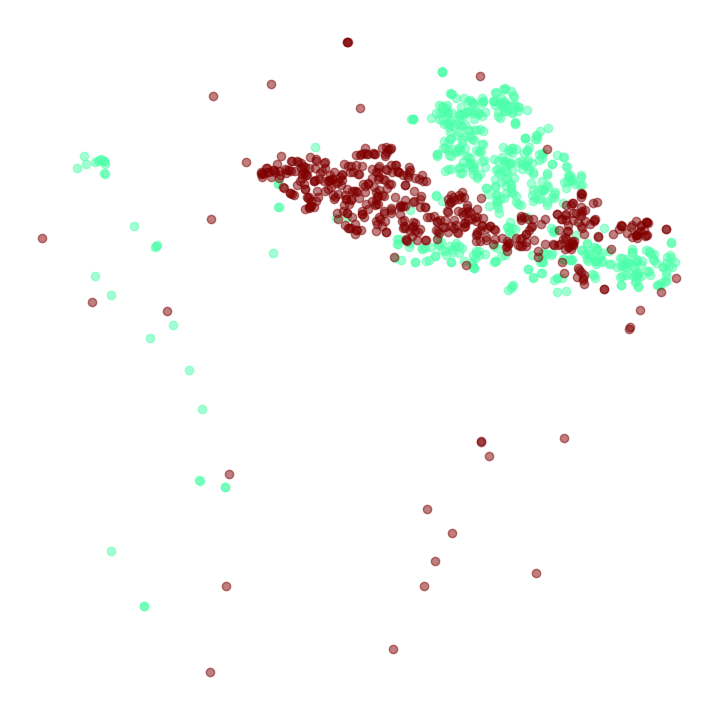

In [55]:
plt.figure(figsize=(9, 9))
cmap = plt.cm.jet
for digit in ('4', '9'):
    plt.scatter(X_reduced[y_sample == digit, 0], X_reduced[y_sample == digit, 1],
                c=[cmap(float(digit) / 9)], alpha=0.5)
plt.axis('off')
plt.show()

In [56]:
idx = (y_sample == '4') | (y_sample == '9')
X_subset = X_sample[idx]
y_subset = y_sample[idx]

tsne_subset = TSNE(n_components=2, init="random", learning_rate="auto",
                   random_state=42)
X_subset_reduced = tsne_subset.fit_transform(X_subset)

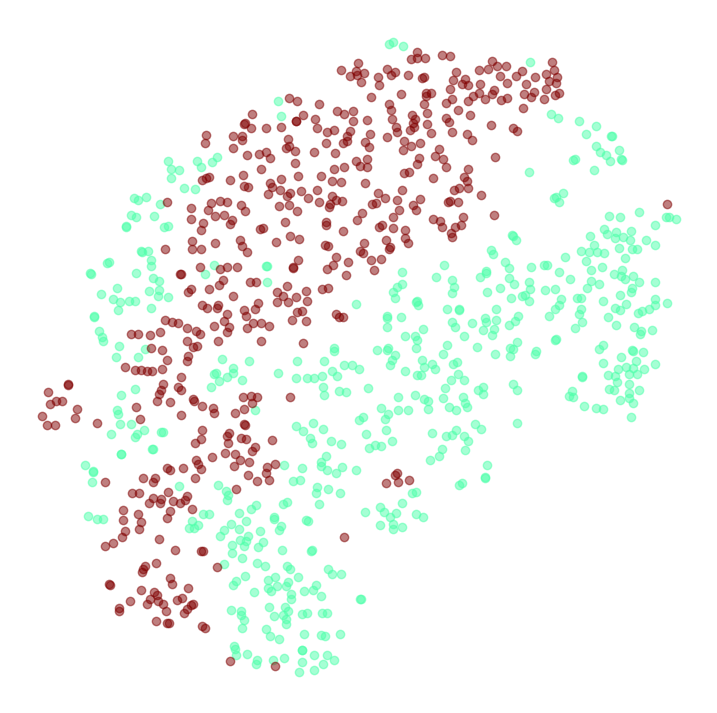

In [57]:
plt.figure(figsize=(9, 9))
for digit in ('4', '9'):
    plt.scatter(X_subset_reduced[y_subset == digit, 0],
                X_subset_reduced[y_subset == digit, 1],
                c=[cmap(float(digit) / 9)], alpha=0.5)
plt.axis('off')
plt.show()

In [58]:
from sklearn.preprocessing import MinMaxScaler
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

def plot_digits(X, y, min_distance=0.04, images=None, figsize=(13, 10)):
    # Let's scale the input features so that they range from 0 to 1
    X_normalized = MinMaxScaler().fit_transform(X)
    # Now we create the list of coordinates of the digits plotted so far.
    # We pretend that one is already plotted far away at the start, to
    # avoid `if` statements in the loop below
    neighbors = np.array([[10., 10.]])
    # The rest should be self-explanatory
    plt.figure(figsize=figsize)
    cmap = plt.cm.jet
    digits = np.unique(y)
    for digit in digits:
        plt.scatter(X_normalized[y == digit, 0], X_normalized[y == digit, 1],
                    c=[cmap(float(digit) / 9)], alpha=0.5)
    plt.axis("off")
    ax = plt.gca()  # get current axes
    for index, image_coord in enumerate(X_normalized):
        closest_distance = np.linalg.norm(neighbors - image_coord, axis=1).min()
        if closest_distance > min_distance:
            neighbors = np.r_[neighbors, [image_coord]]
            if images is None:
                plt.text(image_coord[0], image_coord[1], str(int(y[index])),
                         color=cmap(float(y[index]) / 9),
                         fontdict={"weight": "bold", "size": 16})
            else:
                image = images[index].reshape(28, 28)
                imagebox = AnnotationBbox(OffsetImage(image, cmap="binary"),
                                          image_coord)
                ax.add_artist(imagebox)

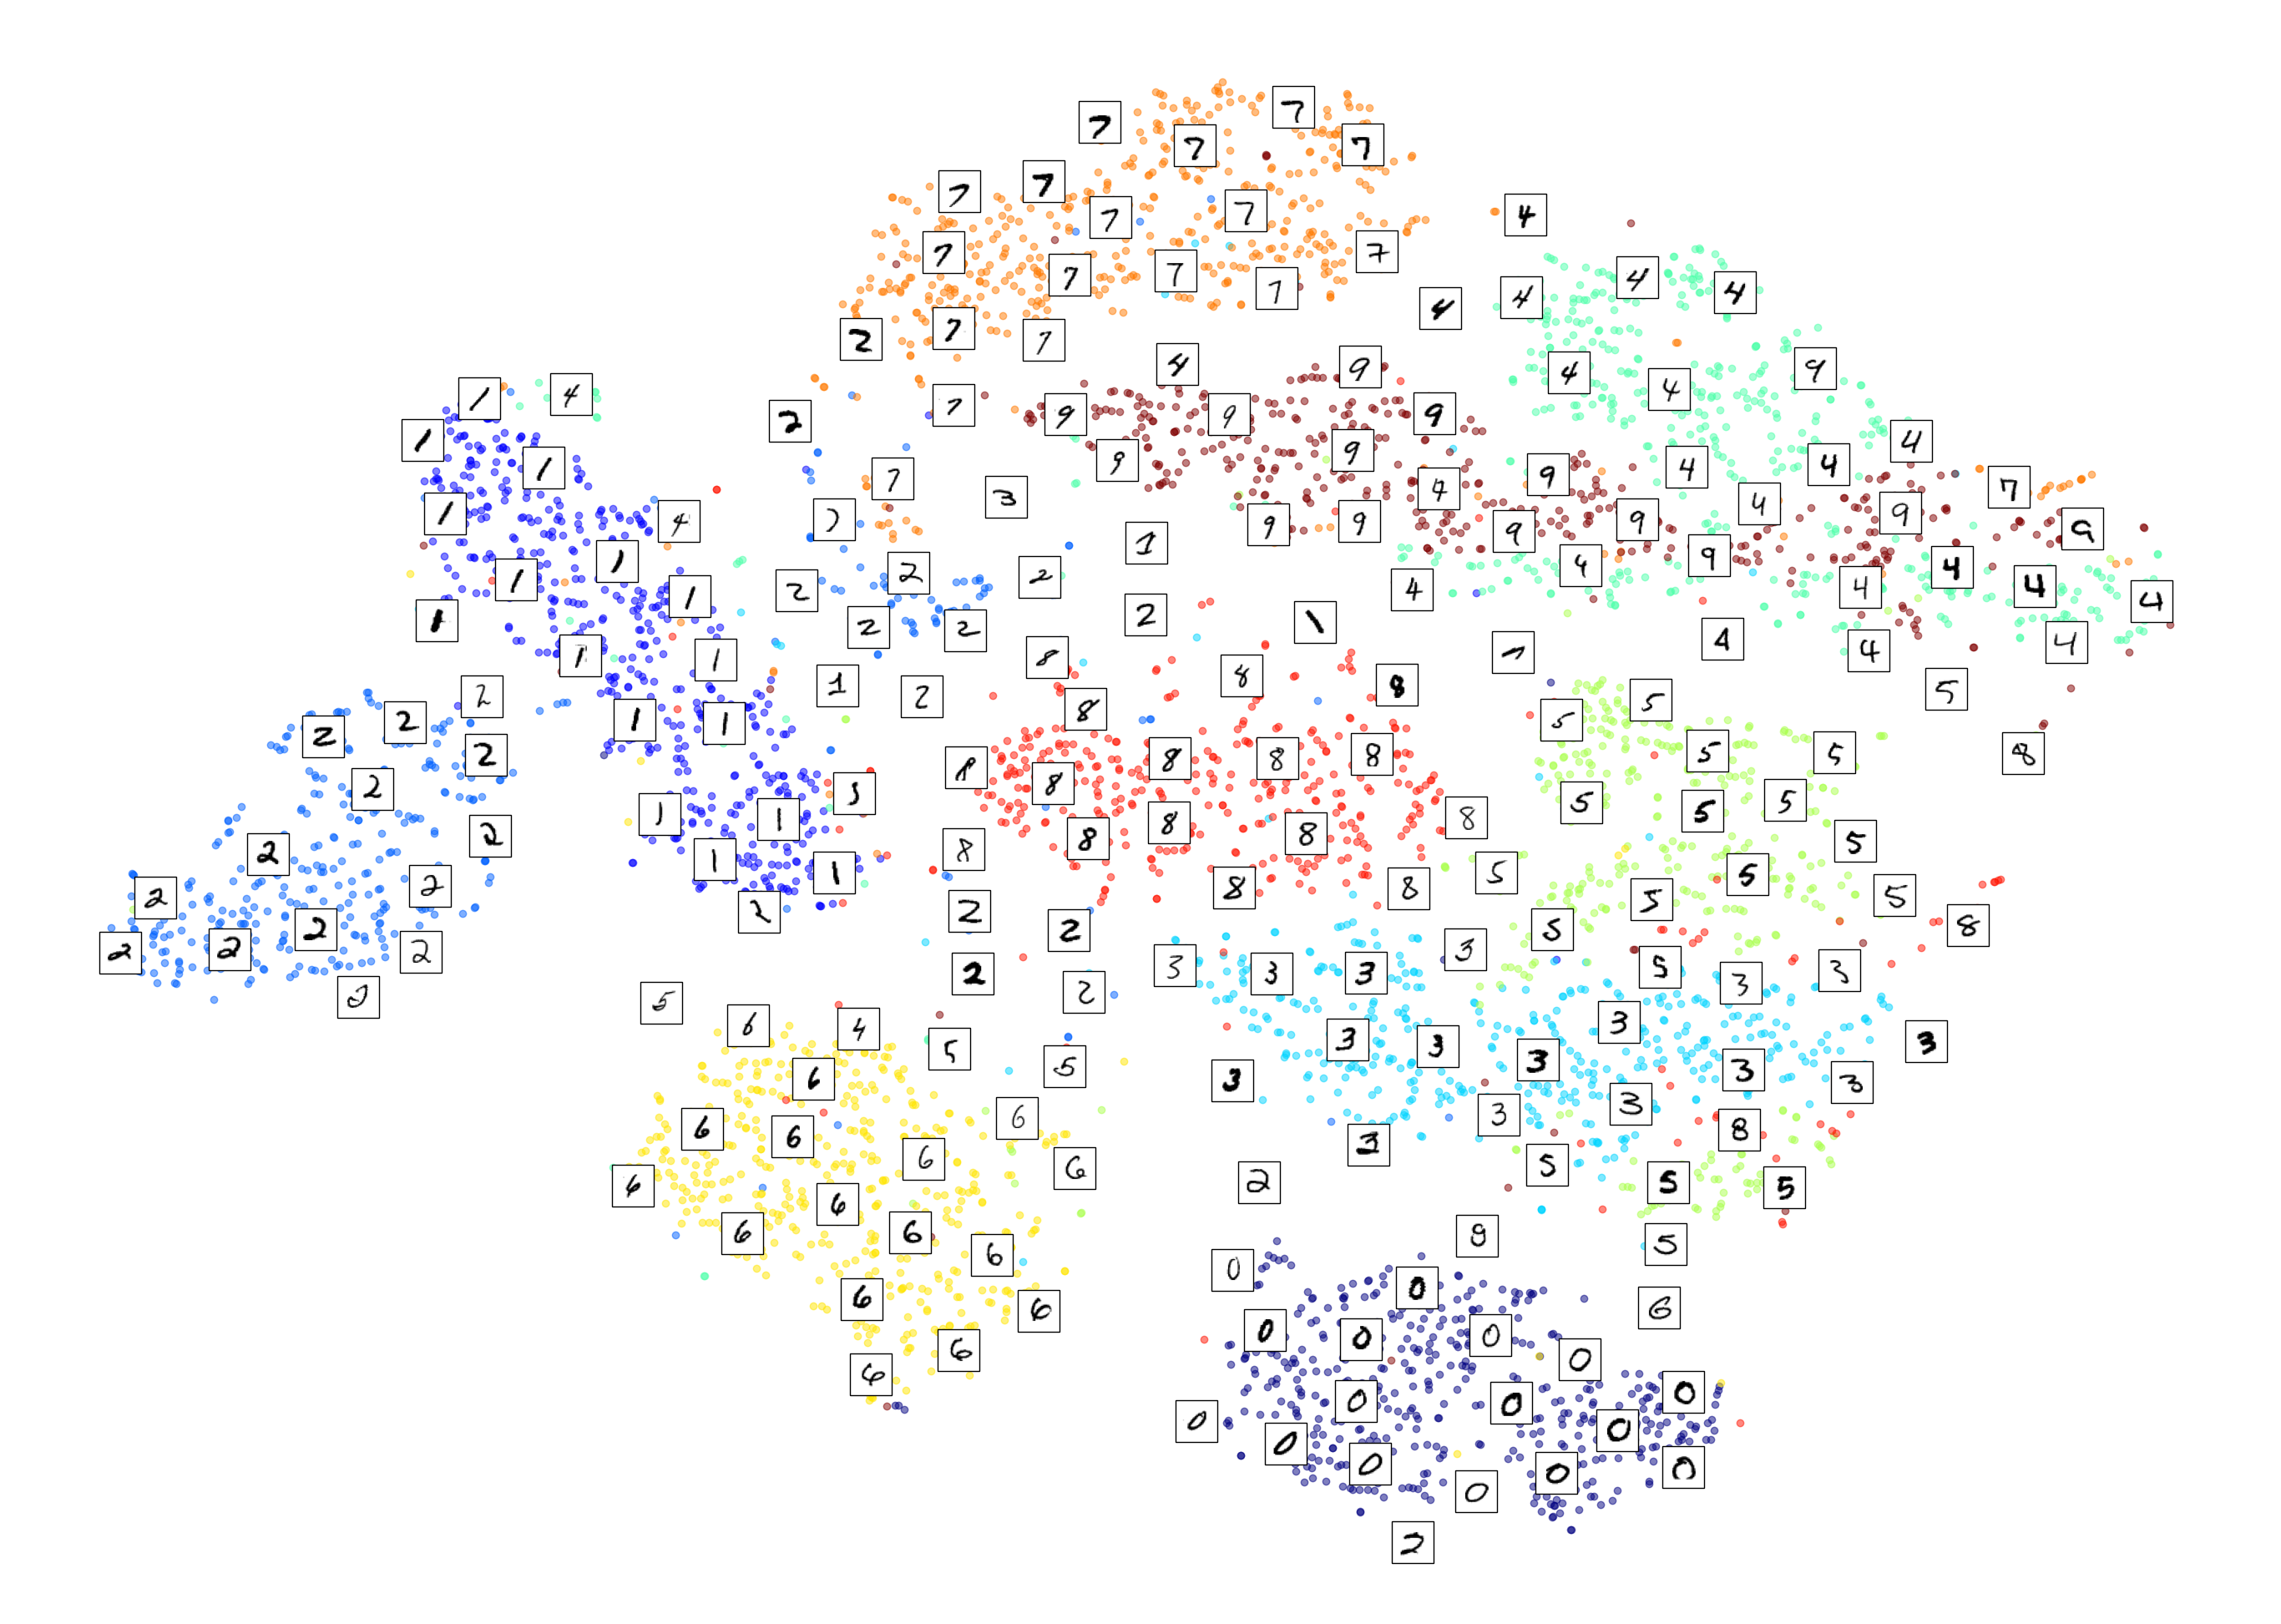

In [59]:
plot_digits(X_reduced, y_sample, images=X_sample, figsize=(35, 25))

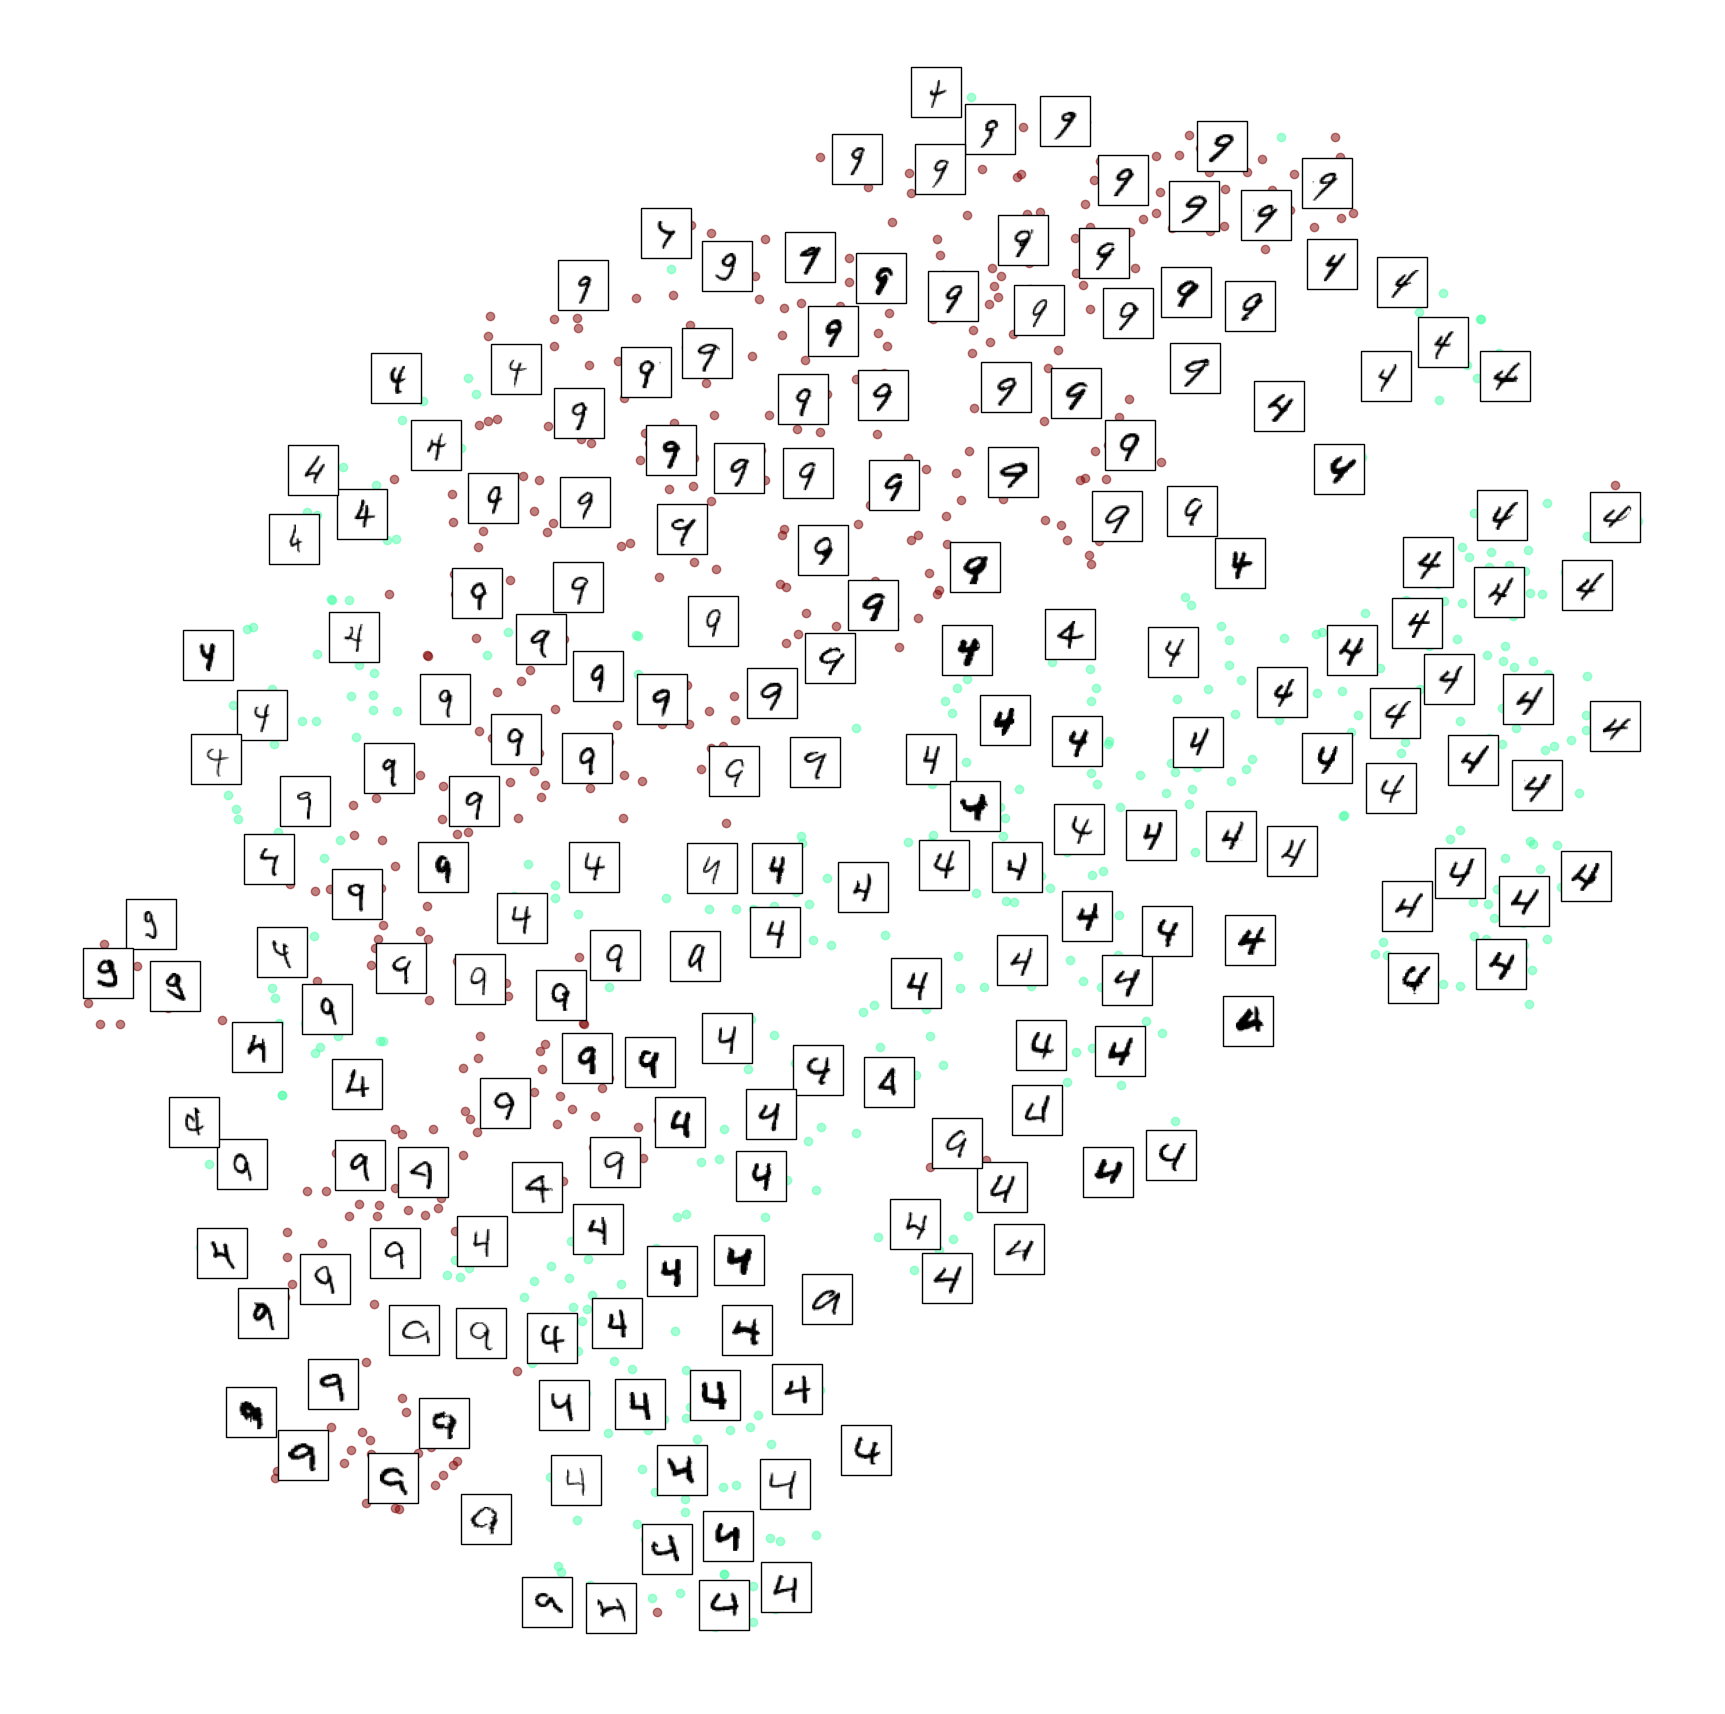

In [60]:
plot_digits(X_subset_reduced, y_subset, images=X_subset, figsize=(22, 22))

CPU times: user 578 ms, sys: 13.9 ms, total: 592 ms
Wall time: 561 ms


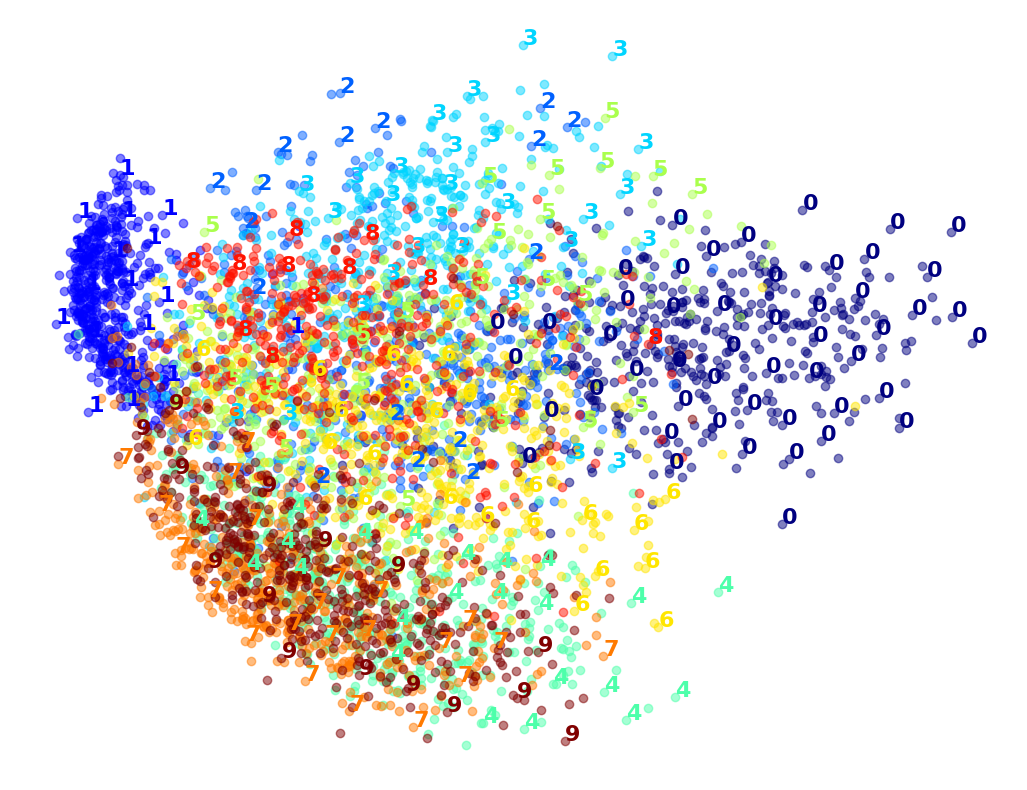

In [61]:
# Using PCA
pca = PCA(n_components=2, random_state=42)
%time X_pca_reduced = pca.fit_transform(X_sample)
plot_digits(X_pca_reduced, y_sample)
plt.show()

CPU times: user 3.64 s, sys: 46.7 ms, total: 3.69 s
Wall time: 3.74 s


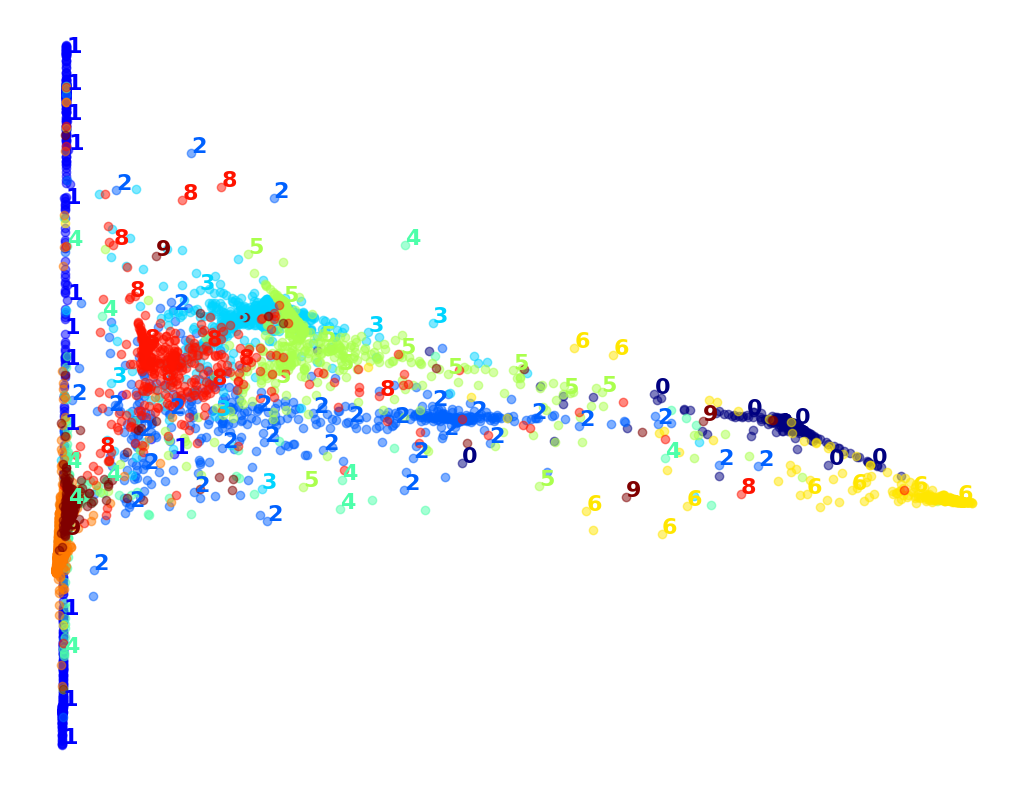

In [62]:
# Using LLE
lle = LocallyLinearEmbedding(n_components=2, random_state=42)
%time X_lle_reduced = lle.fit_transform(X_sample)
plot_digits(X_lle_reduced, y_sample)
plt.show()

CPU times: user 4.29 s, sys: 29.9 ms, total: 4.32 s
Wall time: 3.18 s


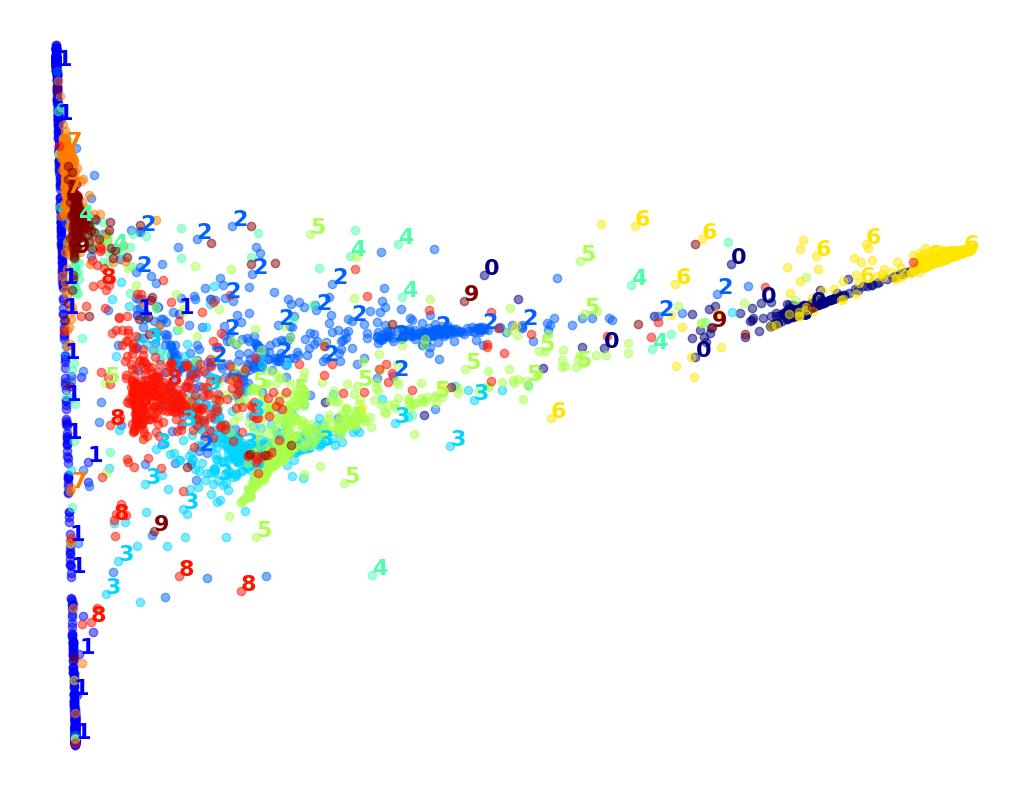

In [63]:
# Using PCA first
pca_lle = make_pipeline(PCA(n_components=0.95),
                        LocallyLinearEmbedding(n_components=2, random_state=42))

%time X_pca_lle_reduced = pca_lle.fit_transform(X_sample)
plot_digits(X_pca_lle_reduced, y_sample)
plt.show()

CPU times: user 14min 7s, sys: 3min 49s, total: 17min 57s
Wall time: 14min 29s


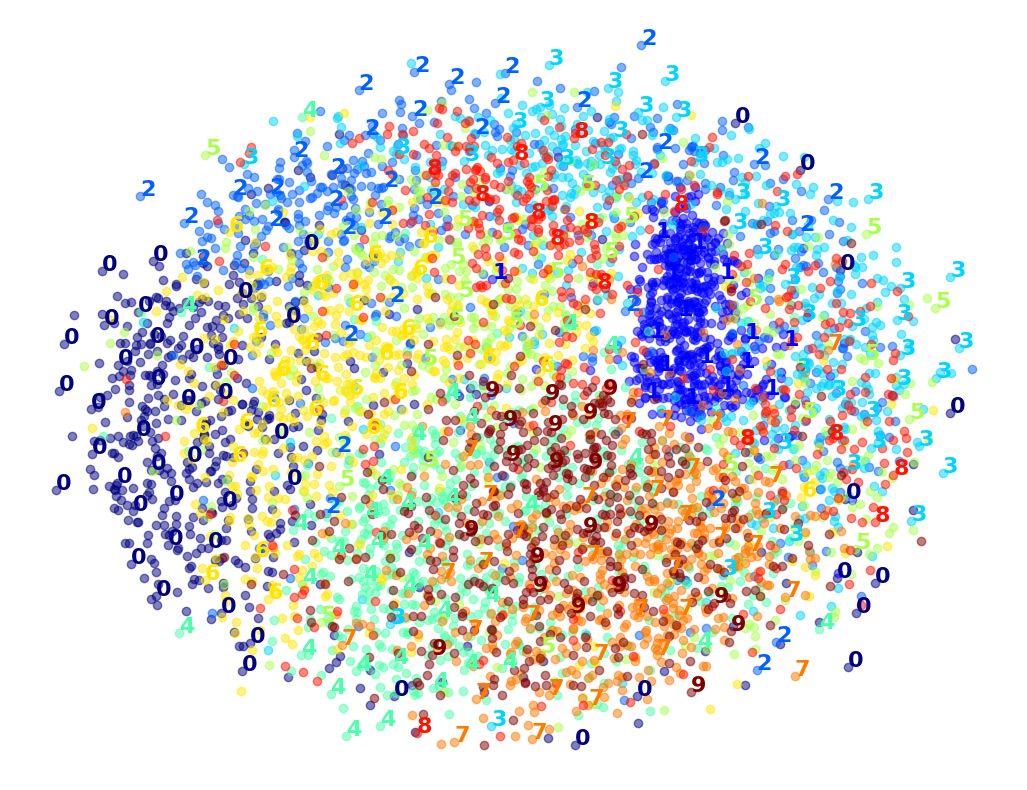

In [64]:
# Using MDS
%time X_mds_reduced = MDS(n_components=2, normalized_stress=False, random_state=42).fit_transform(X_sample)
plot_digits(X_mds_reduced, y_sample)
plt.show()

CPU times: user 14min 11s, sys: 3min 50s, total: 18min 2s
Wall time: 14min 33s


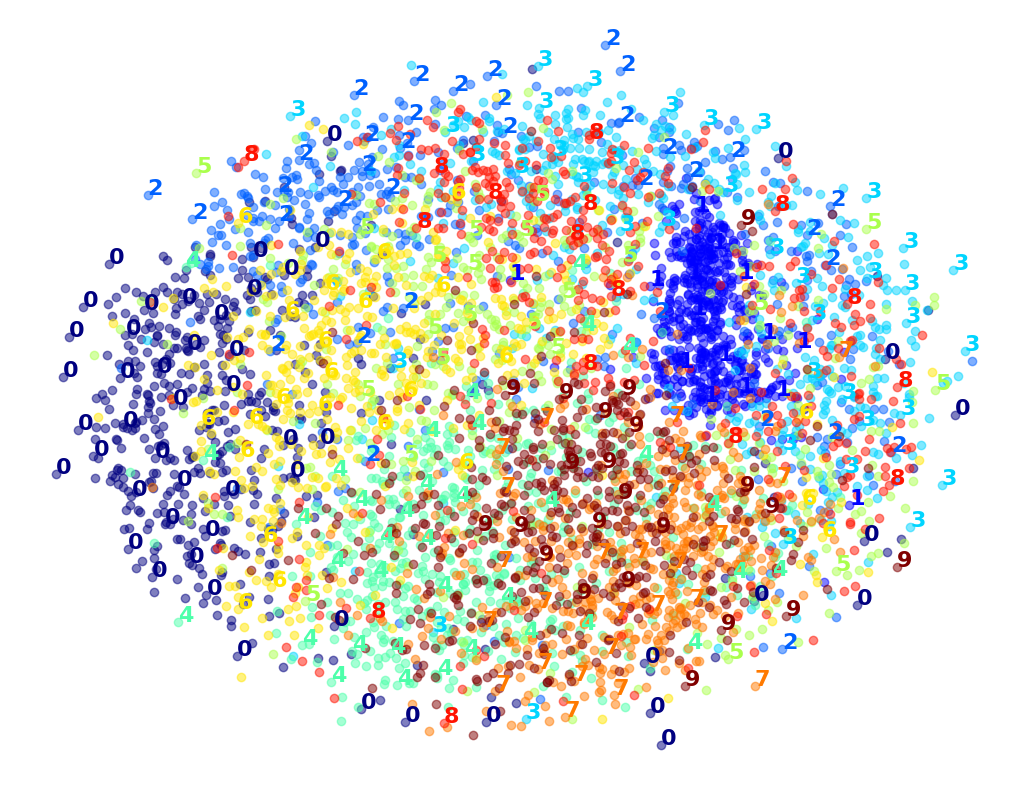

In [65]:
pca_mds = make_pipeline(
    PCA(n_components=0.95, random_state=42),
    MDS(n_components=2, normalized_stress=False, random_state=42)
)

%time X_pca_mds_reduced = pca_mds.fit_transform(X_sample)
plot_digits(X_pca_mds_reduced, y_sample)
plt.show()

CPU times: user 2.63 s, sys: 165 ms, total: 2.79 s
Wall time: 1.7 s


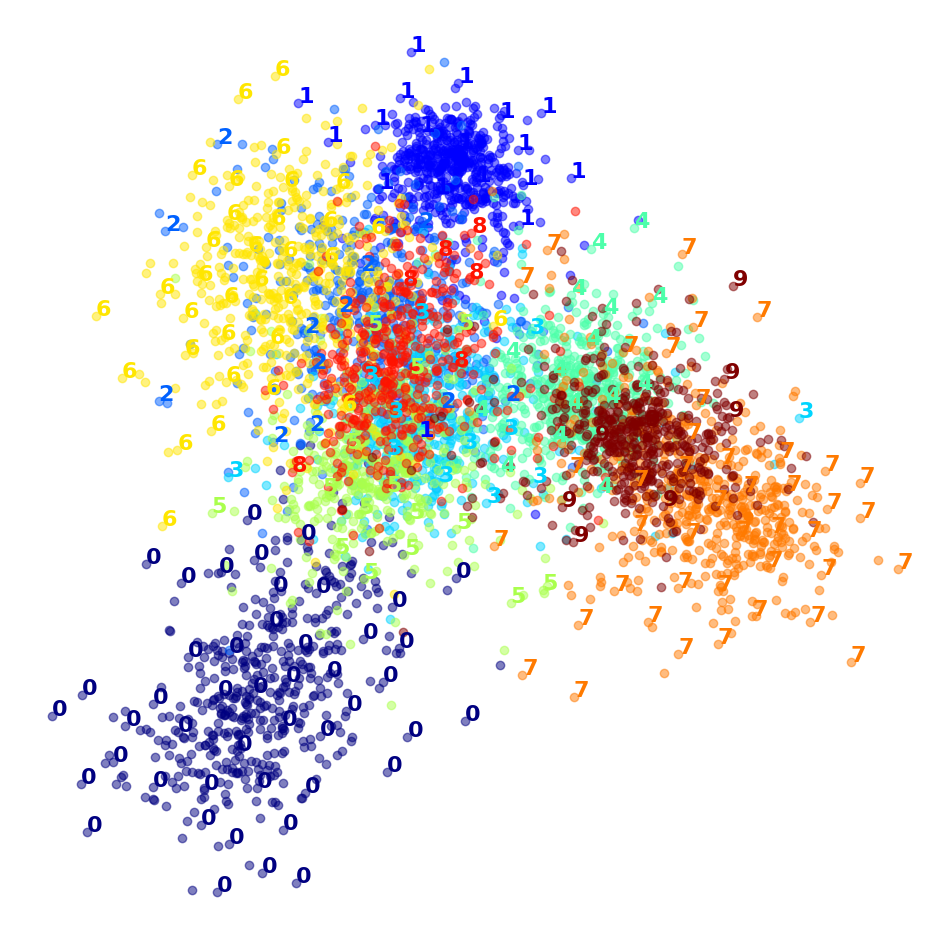

In [66]:
# Using LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
%time X_lda_reduced = lda.fit_transform(X_sample, y_sample)
plot_digits(X_lda_reduced, y_sample, figsize=(12, 12))
plt.show()

t-SNE gives better result